# miDGD — Minimal Usage Demo

End-to-end example: load a trained miDGD model, prepare mRNA test data, optimise per-sample representations, and predict miRNA expression.

**Run from the repository root** (the directory that contains `base/`, `models/`, `data/`).

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from torch.utils.data import DataLoader

from base.data.combined import GeneExpressionDatasetCombined
from base.engine.predict import learn_new_representation
from notebook.model_functions import load_trained_model

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


## 1. Load trained model

Available checkpoints in `models/`:

| File | Training data |
|------|--------------|
| `1-tcga.pth` | TCGA only |
| `2-gtex.pth` | GTEx only |
| `3a-tcga-gtex.pth` | TCGA + GTEx, full miRNA names |
| `3b-tcga-gtex-collapsed.pth` | TCGA + GTEx, collapsed miRNA |
| `4a-tcga-gtex-r2.pth` | Second-round joint model |
| `4b-tcga-gtex-r2-collapsed.pth` | Second-round, collapsed miRNA |
| `5-tcga-gtex-r2-smartseq.pth` | With PSCSR SmartSeq |

In [3]:
dgd = load_trained_model("1-tcga.pth", device=device)
dgd.eval()
print(f"Latent dim : {dgd.rep_dim}")
print(f"GMM components: {dgd.gmm.n_mix_comp}")

Latent dim : 30
GMM components: 70


## 2. Load and prepare data

We use the TCGA held-out test split as example input. To use your own data, supply:
- `mrna_test`: a `samples × genes` DataFrame of raw mRNA counts (gene names must match the training gene set)
- `mirna_test`: a matching `samples × miRNAs` DataFrame (only needed for evaluation)
- `anno_test`: an annotation DataFrame with columns `cancer_type`, `primary_site`, `tissue_type`, `color`, `batch`

In [4]:
datadir = "data/TCGA/miDGD/"

df_mrna   = pd.read_table(datadir + "tcga_mrna.tsv",        sep="\t", index_col=0)
df_mirna  = pd.read_table(datadir + "tcga_mirna.tsv",       sep="\t", index_col=0)
anno_test = pd.read_table(datadir + "TCGA_test_anno.tsv",   sep="\t", index_col=0)
anno_test["batch"] = "TCGA"  # required column

# subset to test samples
mrna_test  = df_mrna.loc[anno_test.index]
mirna_test = df_mirna.loc[anno_test.index]

print(f"Test set: {mrna_test.shape[0]} samples × {mrna_test.shape[1]} genes, {mirna_test.shape[1]} miRNAs")

Test set: 1205 samples × 18393 genes, 755 miRNAs


In [5]:
test_dataset = GeneExpressionDatasetCombined(
    mrna_test, mirna_test, anno_test, scaling_type="sum"
)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
print(f"DataLoader: {len(test_loader)} batches of up to 256")

DataLoader: 5 batches of up to 256


## 3. Learn new representations

`learn_new_representation` optimises a per-sample latent vector for the test data using the mRNA reconstruction loss. The decoder weights stay **frozen** — only the new `RepresentationLayer` is updated.

In [6]:
test_rep = learn_new_representation(
    dgd,
    test_loader,
    test_epochs=50,
    learning_rates=1e-2,
)
print("Learned representation shape:", test_rep.z.shape)

100%|██████████| 50/50 [00:43<00:00,  1.15it/s]

Learned representation shape: torch.Size([1205, 30])


## 4. Decode to get miRNA predictions

The decoder returns `[X_mirna, X_mrna]` as softmax probabilities. Multiplying by the sample's total miRNA library size converts to predicted counts.

In [7]:
dgd.eval()
with torch.no_grad():
    X_mirna_prob, _ = dgd.decoder(test_rep.z.to(device))
    mirna_lib = torch.nansum(
        torch.tensor(mirna_test.values, dtype=torch.float32), dim=-1
    ).unsqueeze(1).to(device)
    X_mirna_pred = (X_mirna_prob * mirna_lib).cpu().numpy()

pred_df = pd.DataFrame(X_mirna_pred, index=mirna_test.index, columns=mirna_test.columns)
print("Prediction shape:", pred_df.shape)
pred_df.iloc[:3, :5]

Prediction shape: (1205, 755)


,hsa-let-7a-2-3p,hsa-let-7a-3p,hsa-let-7b-3p,hsa-let-7b-5p,hsa-let-7c-3p
sample_id,,,,,
TCGA-IG-A3YA-01A-11R-A24K-31,45.301868,122.022491,150.591339,71175.789062,302.048035
TCGA-A5-A0GA-01A-11R-A040-07,5.019567,60.588760,42.578732,21576.185547,28.198328
TCGA-AB-2984-03A-01T-0734-13,102.352882,264.720764,218.361862,32551.673828,155.860443


## 5. Evaluation: per-miRNA Spearman correlation

Median Spearman r: 0.613
Mean   Spearman r: 0.559


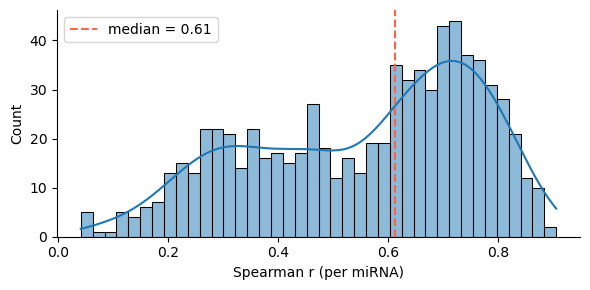

In [8]:
true = mirna_test.values.astype(float)
pred = pred_df.values

corrs = [
    stats.spearmanr(true[:, j], pred[:, j]).statistic
    for j in range(true.shape[1])
    if true[:, j].std() > 0
]

print(f"Median Spearman r: {np.median(corrs):.3f}")
print(f"Mean   Spearman r: {np.mean(corrs):.3f}")

plt.figure(figsize=(6, 3))
sns.histplot(corrs, bins=40, kde=True)
plt.axvline(np.median(corrs), color="tomato", linestyle="--",
            label=f"median = {np.median(corrs):.2f}")
plt.xlabel("Spearman r (per miRNA)")
plt.ylabel("Count")
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

## 6. Visualise latent space

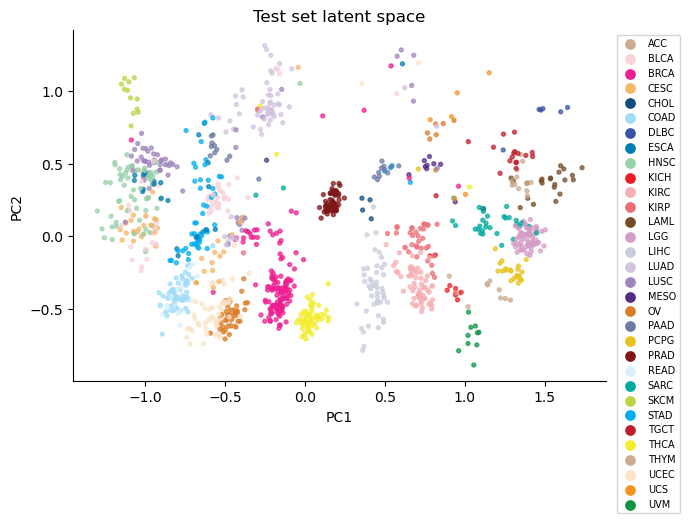

In [9]:
from sklearn.decomposition import PCA

z = test_rep.z.detach().cpu().numpy()
z_2d = PCA(n_components=2).fit_transform(z)

color_map = dict(zip(anno_test["cancer_type"], anno_test["color"]))
colors = [color_map.get(ct, "#888888") for ct in anno_test["cancer_type"]]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(z_2d[:, 0], z_2d[:, 1], c=colors, s=8, alpha=0.7)
for ct, col in sorted(color_map.items()):
    ax.scatter([], [], c=col, label=ct, s=20)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7, markerscale=1.5)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Test set latent space")
sns.despine()
plt.tight_layout()
plt.show()